### Utility-Based Metrics
Standard metrics (MSE, MAE) ignore the importance of rare extreme delays.  
Following the imbalanced regression literature, we implement:

$$prec^\phi = \frac{\sum_i \phi(\hat{y}_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(\hat{y}_i)}$$

$$rec^\phi = \frac{\sum_i \phi(y_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(y_i)}$$

$$F_1^\phi = \frac{2 \cdot prec^\phi \cdot rec^\phi}{prec^\phi + rec^\phi}$$

Where $\theta$ is an acceptable error tolerance (default: 30 min).

In [1]:
import joblib

print("Loading data from disk...")
pipeline_inputs = joblib.load('pipeline_inputs.joblib')

datasets = pipeline_inputs['datasets']
X_test   = pipeline_inputs['X_test']
y_test   = pipeline_inputs['y_test']
phi_test = pipeline_inputs['phi_test']

print("Successfully loaded data!")

Loading data from disk...
Successfully loaded data!


### Model Definitions
- **Linear Regression** - baseline linear model  
- **SVR** - support vector regression (with scaling pipeline)  
- **SVR2** - approximate kernel SVR using Nyström feature map + SGD, trading exact kernel computation for linear scalability 
- **Random Forest** - ensemble of decision trees  
- **LightGBM** - gradient boosted trees (extra benchmark)

In [25]:
import pickle
import os

RESULTS_DIR = 'results_cv'

os.makedirs(RESULTS_DIR, exist_ok=True)

all_results = {}
all_models = {}

model_names = ['LinearRegression', 'SVR', 'SVR2', 'LightGBM', 'RandomForest']

trained_dir    = 'trained_cv'
evaluated_dir = 'evaluated_cv'

for model_name in model_names:
    model_files = sorted([
        f for f in os.listdir(trained_dir)
        if f.startswith(f'{model_name}_sample') and f.endswith('.pkl')
    ])

    for fname in model_files:
        # extract sample tag: "{model_name}_sample{tag}.pkl" -> "0_5", "1_0", etc.
        sample_tag = fname[len(f'{model_name}_sample'):-len('.pkl')]

        models_path  = os.path.join(trained_dir,    fname)
        results_path = os.path.join(evaluated_dir, fname)

        if os.path.exists(models_path):
            with open(models_path, 'rb') as f:
                saved_models = pickle.load(f)
            for strategy, model in saved_models.items():
                all_models[(model_name, sample_tag, strategy)] = model
            print(f'  Loaded models  : {model_name} sample={sample_tag} — {len(saved_models)} strategies')

        if os.path.exists(results_path):
            with open(results_path, 'rb') as f:
                model_results = pickle.load(f)
            for strategy, metrics in model_results.items():
                all_results[(model_name, sample_tag, strategy)] = metrics
            print(f'  Loaded results : {model_name} sample={sample_tag} — {len(model_results)} strategies')
all_results = dict(
    sorted(all_results.items(), key=lambda x: (model_names.index(x[0][0]), x[0][1], x[0][2]))
)
print(f'\nTotal models  loaded: {len(all_models)}')
print(f'Total results loaded: {len(all_results)}')

  Loaded models  : LinearRegression sample=1_0 — 6 strategies
  Loaded results : LinearRegression sample=1_0 — 6 strategies
  Loaded models  : SVR sample=0_0001 — 6 strategies
  Loaded results : SVR sample=0_0001 — 6 strategies
  Loaded models  : SVR2 sample=0_2 — 6 strategies
  Loaded results : SVR2 sample=0_2 — 6 strategies
  Loaded models  : LightGBM sample=0_1 — 6 strategies
  Loaded results : LightGBM sample=0_1 — 6 strategies
  Loaded models  : RandomForest sample=0_01 — 6 strategies
  Loaded results : RandomForest sample=0_01 — 6 strategies

Total models  loaded: 30
Total results loaded: 30


### Results Table

In [26]:
import pandas as pd

results_df = pd.DataFrame(all_results).T
results_df.index.names = ['Model', 'Sample', 'Strategy']
results_df = results_df[[
    'f1_phi', 'prec_phi', 'rec_phi',
    'Weighted_MAE', 'MAE', 'RMSE',
    'Tail_MAE', 'Tail_RMSE', 'tail_n'
]]
results_df.round(4).reset_index().to_csv(f'{RESULTS_DIR}/results.csv', index=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(results_df.round(4))

f1_phi  prec_phi  rec_phi  Weighted_MAE  \
Model            Sample Strategy                                              
LinearRegression 1_0    Baseline    0.8544    0.8908   0.8210       30.0779   
                        GaussNoise  0.2020    0.1608   0.2715       42.7609   
                        RO          0.5425    0.4698   0.6418       34.6640   
                        RU          0.6869    0.6453   0.7342       33.1410   
                        SMOTER      0.5333    0.4595   0.6352       34.6215   
                        WERCS       0.7322    0.7053   0.7613       32.7866   
SVR              0_0001 Baseline    0.8396    0.8840   0.7995       29.6351   
                        GaussNoise  0.7436    0.7240   0.7643       31.8530   
                        RO          0.8424    0.8828   0.8055       29.6744   
                        RU          0.8415    0.8836   0.8033       29.6847   
                        SMOTER      0.8440    0.8834   0.8079       29.6614   
                        WERCS       0.8403    0.8833   0.8014       29.6727   
SVR2             0_2    Baseline    0.8352    0.8752   0.7987       29.6621   
                        GaussNoise  0.8674    0.9002   0.8369       31.6212   
                        RO          0.8357    0.8745   0.8001       29.6616   
                        RU          0.8353    0.8725   0.8011       29.6623   
                        SMOTER      0.8356    0.8741   0.8003       29.6598   
                        WERCS       0.8340    0.8734   0.7981       29.6621   
LightGBM         0_1    Baseline    0.8013    0.8526   0.7558       27.0654   
                        GaussNoise  0.8145    0.8533   0.7792       26.4120   
                        RO          0.8146    0.8503   0.7818       26.3327   
                        RU          0.8102    0.8492   0.7746       26.3540   
                        SMOTER      0.8057    0.8488   0.7668       26.6921   
                        WERCS       0.7717    0.7631   0.7805       27.8518   
RandomForest     0_01   Baseline    0.8200    0.8335   0.8069       29.0557   
                        GaussNoise  0.6764    0.6309   0.7291       32.5771   
                        RO          0.6112    0.5487   0.6898       33.2996   
                        RU          0.6988    0.6590   0.7437       32.0926   
                        SMOTER      0.7044    0.6665   0.7469       31.5467   
                        WERCS       0.3095    0.2362   0.4490       39.8934   

                                        MAE     RMSE  Tail_MAE  Tail_RMSE  \
Model            Sample Strategy                                            
LinearRegression 1_0    Baseline    22.1970  50.7606  125.6312   182.2407   
                        GaussNoise  41.4811  57.6661   97.4144   164.1885   
                        RO          30.3240  52.3431  112.1852   173.3628   
                        RU          27.9244  51.6012  115.8270   175.7192   
                        SMOTER      30.2622  52.3432  112.1303   173.3584   
                        WERCS       27.3363  51.4519  116.7299   176.3097   
SVR              0_0001 Baseline    20.1653  51.1441  131.6596   186.2798   
                        GaussNoise  25.7129  51.2527  118.4845   177.6488   
                        RO          20.6184  50.9812  130.1048   185.2391   
                        RU          20.4764  51.0429  130.7170   185.6350   
                        SMOTER      20.7677  50.9234  129.3686   184.7650   
                        WERCS       20.3341  51.0957  131.1960   185.9604   
SVR2             0_2    Baseline    20.1619  51.1695  131.8101   186.3798   
                        GaussNoise  25.2318  51.0082  121.0285   179.1082   
                        RO          20.1638  51.1680  131.8004   186.3733   
                        RU          20.1626  51.1693  131.8087   186.3788   
                        SMOTER      20.1752  51.1601  131.7467   186.3370   
                        WERCS       20.1619 

### F₁φ Heatmap - Model × Strategy

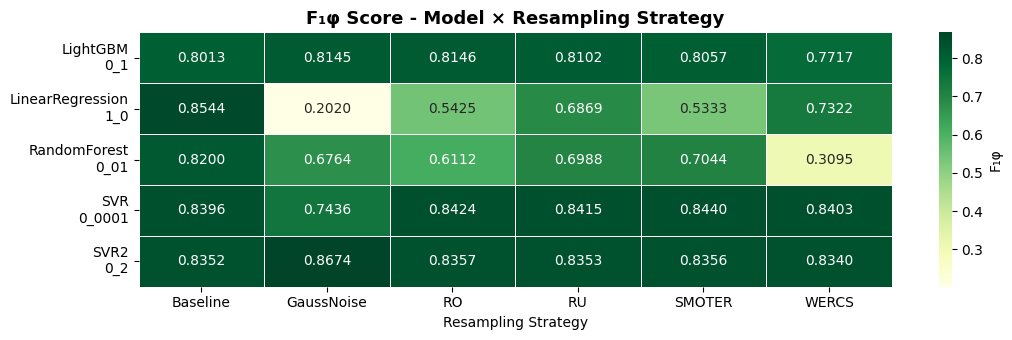

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

f1_pivot = results_df['f1_phi'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, len(f1_pivot) * 0.5 + 1))
sns.heatmap(
    f1_pivot,
    annot=True, fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'F₁φ'}
)

# show model name only on first row of each group
labels = []
for (model, sample) in f1_pivot.index:
    prev = f1_pivot.index[f1_pivot.index.get_loc((model, sample)) - 1] if f1_pivot.index.get_loc((model, sample)) > 0 else None
    labels.append(f'{model}\n{sample}' if prev is None or prev[0] != model else sample)

ax.set_yticklabels(labels, rotation=0)
ax.set_title('F₁φ Score - Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/f1.png')
plt.show()

### Precision & Recall φ - Grouped Bar Chart

C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\800290590.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\800290590.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\800290590.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\800290590.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\8002

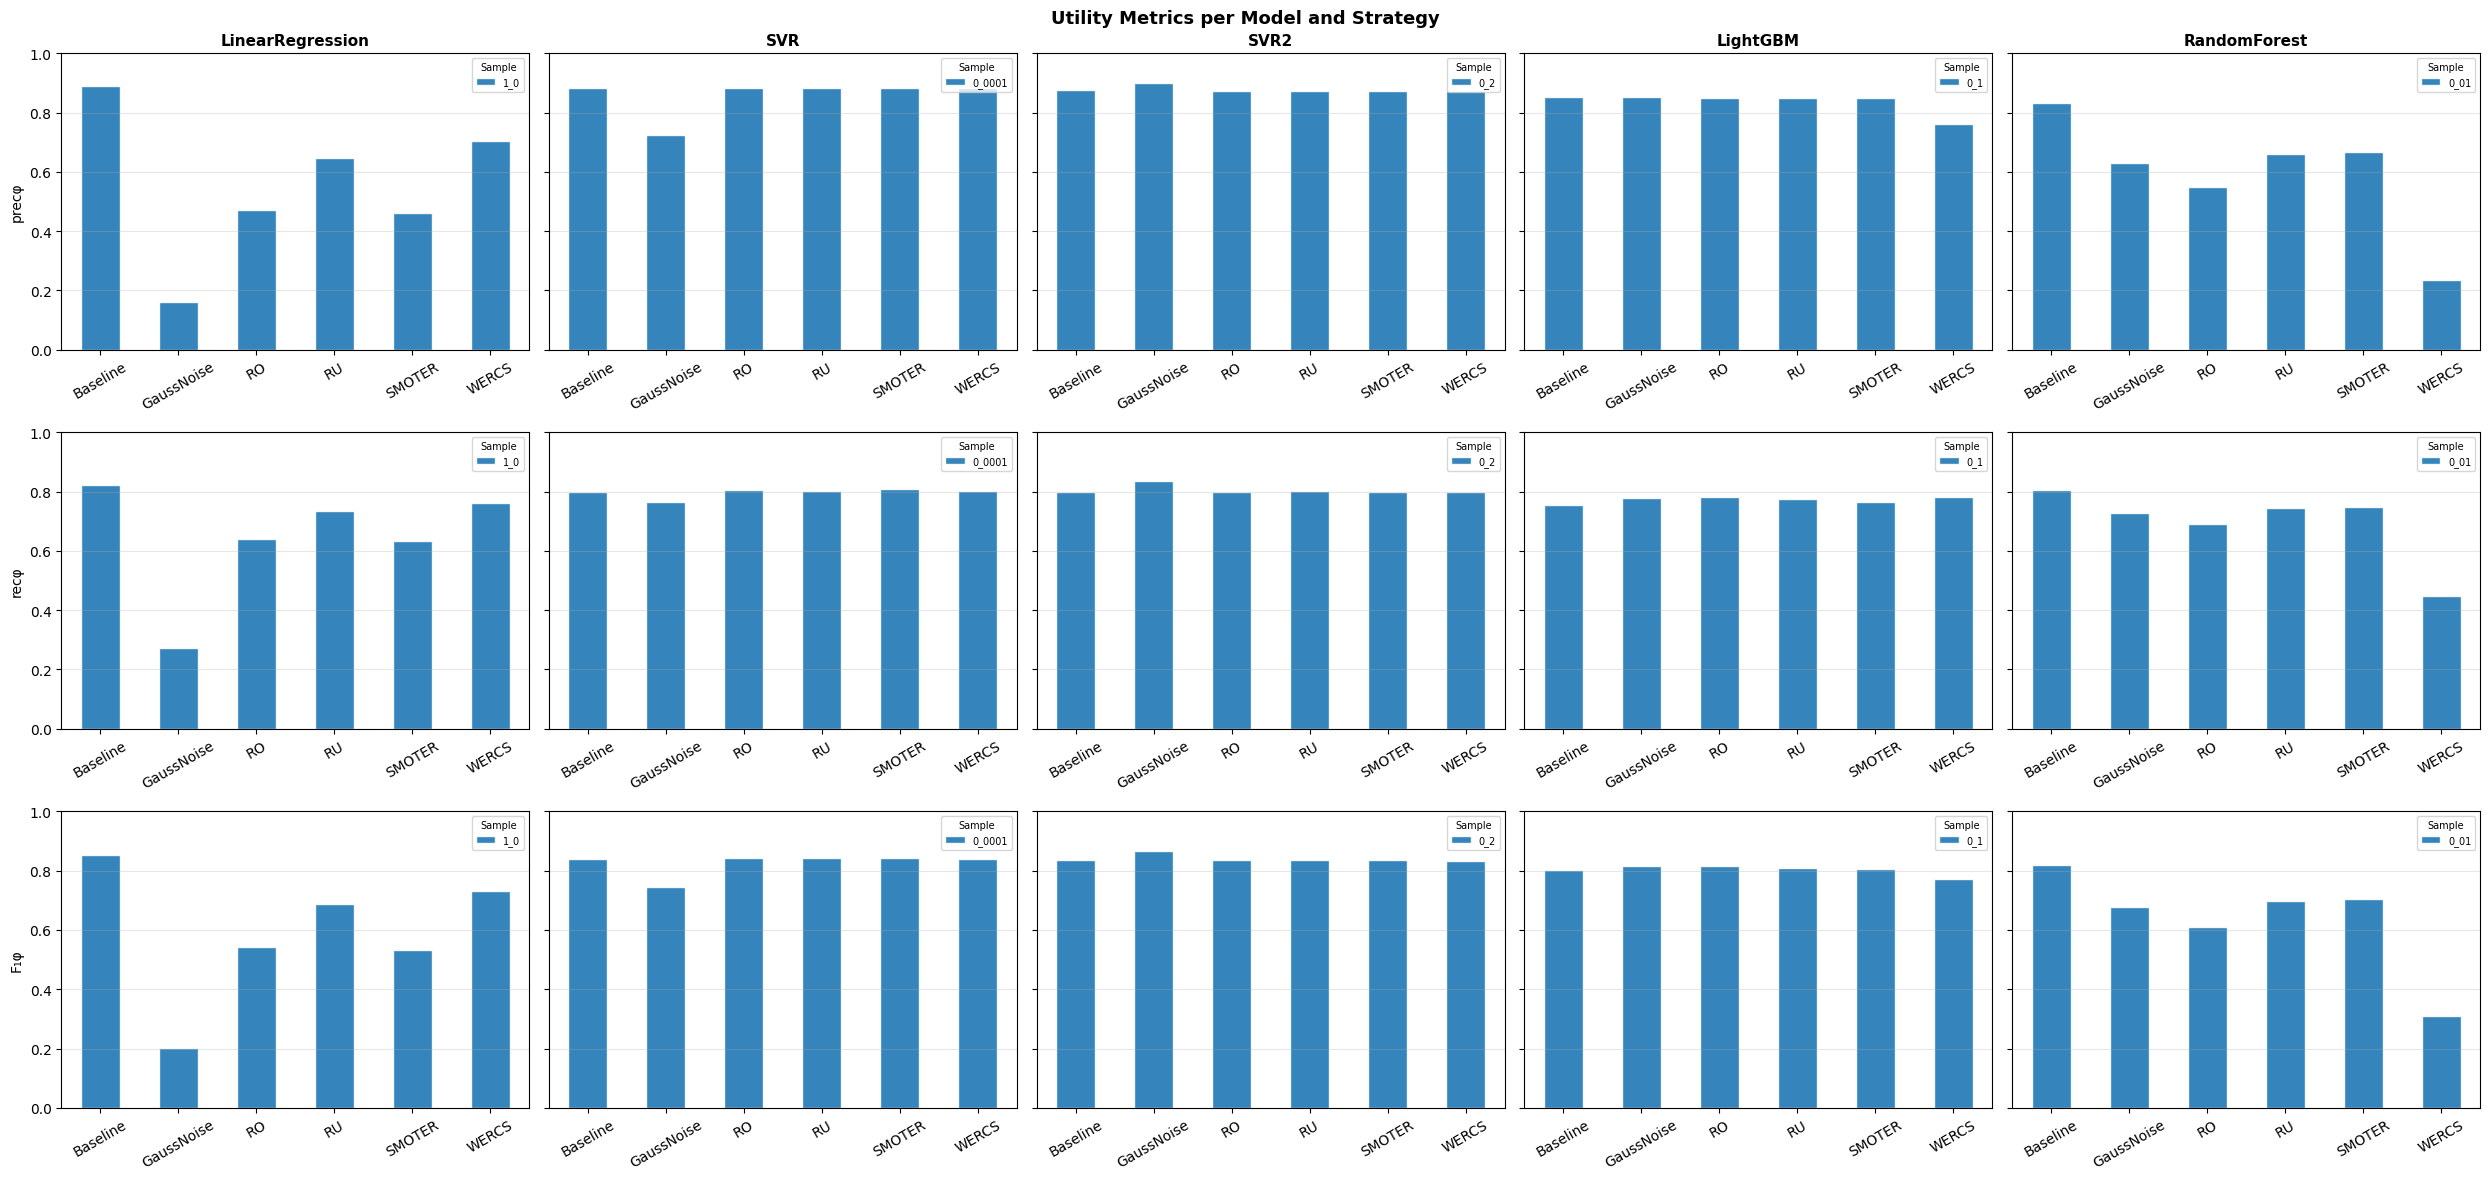

In [14]:
models_list  = results_df.index.get_level_values('Model').unique()
metrics      = ['prec_phi', 'rec_phi', 'f1_phi']
metric_names = ['precφ', 'recφ', 'F₁φ']

fig, axes = plt.subplots(
    len(metrics), len(models_list),
    figsize=(5 * len(models_list), 4 * len(metrics)),
    sharey='row', squeeze=False
)

for col, model_name in enumerate(models_list):
    for row, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        ax = axes[row][col]
        subset = results_df.loc[model_name, metric].unstack('Sample')  # index=Strategy, cols=Sample
        subset.plot.bar(ax=ax, edgecolor='white', alpha=0.9)

        if row == 0:
            ax.set_title(model_name, fontsize=11, weight='bold')
        if col == 0:
            ax.set_ylabel(metric_name, fontsize=10)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(title='Sample', fontsize=7, title_fontsize=7)

plt.suptitle('Utility Metrics per Model and Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/p&r.png', dpi=150)
plt.show()

### Overall MAE Comparison

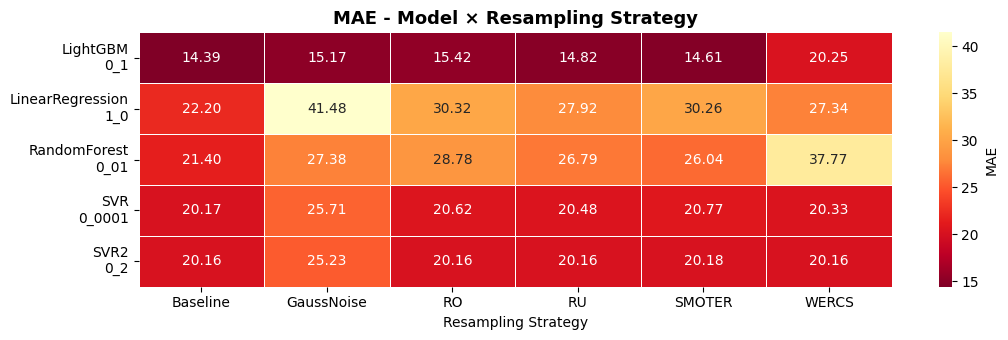

In [15]:
mae_pivot = results_df['MAE'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, len(mae_pivot) * 0.5 + 1))
sns.heatmap(
    mae_pivot,
    annot=True, fmt='.2f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'MAE'}
)

labels = []
for i, (model, sample) in enumerate(mae_pivot.index):
    prev = mae_pivot.index[i - 1] if i > 0 else None
    labels.append(f'{model}\n{sample}' if prev is None or prev[0] != model else sample)

ax.set_yticklabels(labels, rotation=0)
ax.set_title('MAE - Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mae.png')
plt.show()

### Best Combination & Key Findings

In [16]:
best_idx     = results_df['f1_phi'].idxmax()
best_metrics = results_df.loc[best_idx]
print('=== Best combination by F₁φ ===')
print(f'  Model    : {best_idx[0]}')
print(f'  Sample   : {best_idx[1]}')
print(f'  Strategy : {best_idx[2]}')
print(f'  F₁φ      : {best_metrics["f1_phi"]:.4f}')
print(f'  precφ    : {best_metrics["prec_phi"]:.4f}')
print(f'  recφ     : {best_metrics["rec_phi"]:.4f}')
print(f'  MAE      : {best_metrics["MAE"]:.2f} min')
print(f'  RMSE     : {best_metrics["RMSE"]:.2f} min')
print()

rf_wercs_f1 = results_df.loc['RandomForest', 'f1_phi'].xs('WERCS', level='Strategy').max()
print(f'RandomForest + WERCS best F₁φ : {rf_wercs_f1:.4f}')
print(f'Hypothesis confirmed           : {best_idx[0] == "RandomForest" and best_idx[2] == "WERCS"}')
print()

print('=== Best strategy per model (by F₁φ) ===')
for model_name in models_list:
    best_idx_m  = results_df.loc[model_name, 'f1_phi'].idxmax()  # (sample, strategy)
    best_f1     = results_df.loc[(model_name, *best_idx_m), 'f1_phi']
    print(f'  {model_name:<20}: sample={best_idx_m[0]:<8} strategy={best_idx_m[1]:<12}  F₁φ={best_f1:.4f}')

=== Best combination by F₁φ ===
  Model    : SVR2
  Sample   : 0_2
  Strategy : GaussNoise
  F₁φ      : 0.8674
  precφ    : 0.9002
  recφ     : 0.8369
  MAE      : 25.23 min
  RMSE     : 51.01 min

RandomForest + WERCS best F₁φ : 0.3095
Hypothesis confirmed           : False

=== Best strategy per model (by F₁φ) ===
  LinearRegression    : sample=1_0      strategy=Baseline      F₁φ=0.8544
  SVR                 : sample=0_0001   strategy=SMOTER        F₁φ=0.8440
  SVR2                : sample=0_2      strategy=GaussNoise    F₁φ=0.8674
  LightGBM            : sample=0_1      strategy=RO            F₁φ=0.8146
  RandomForest        : sample=0_01     strategy=Baseline      F₁φ=0.8200


C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\138795345.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  rf_wercs_f1 = results_df.loc['RandomForest', 'f1_phi'].xs('WERCS', level='Strategy').max()
C:\Users\Bartosz\AppData\Local\Temp\ipykernel_11252\138795345.py:21: PerformanceWarning: indexing past lexsort depth may impact performance.
  best_idx_m  = results_df.loc[model_name, 'f1_phi'].idxmax()  # (sample, strategy)


### Feature Importance - Random Forest + WERCS

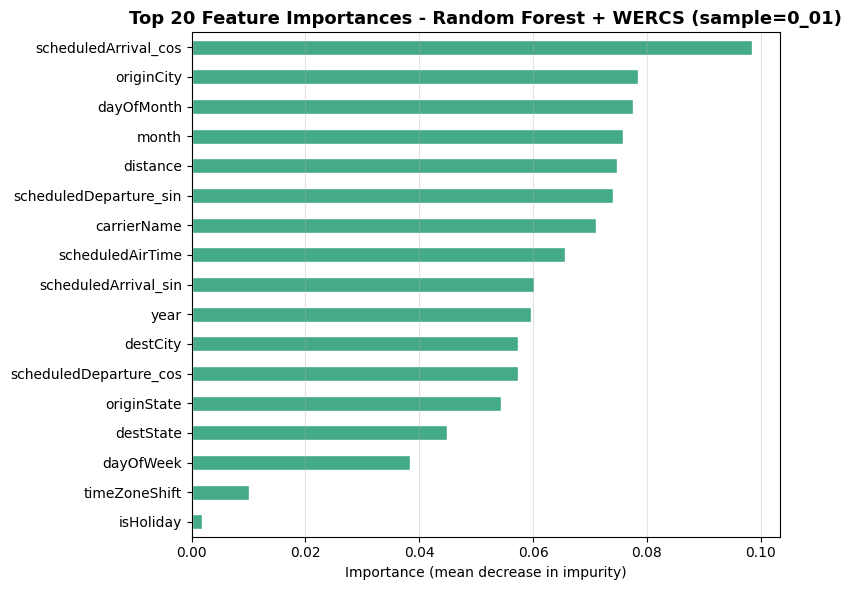

In [17]:
# pick the sample with best f1_phi for RandomForest + WERCS
best_sample = results_df.loc['RandomForest'].xs('WERCS', level='Strategy')['f1_phi'].idxmax()
rf_wercs = all_models[('RandomForest', best_sample, 'WERCS')]

fi = (
    pd.Series(rf_wercs.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(8, 6))
fi.sort_values().plot.barh(ax=ax, color='#44aa88', edgecolor='white')
ax.set_title(f'Top 20 Feature Importances - Random Forest + WERCS (sample={best_sample})', fontsize=13, weight='bold')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fi_wercs_RF.png")

### Residual Distributions - Best Model per Strategy

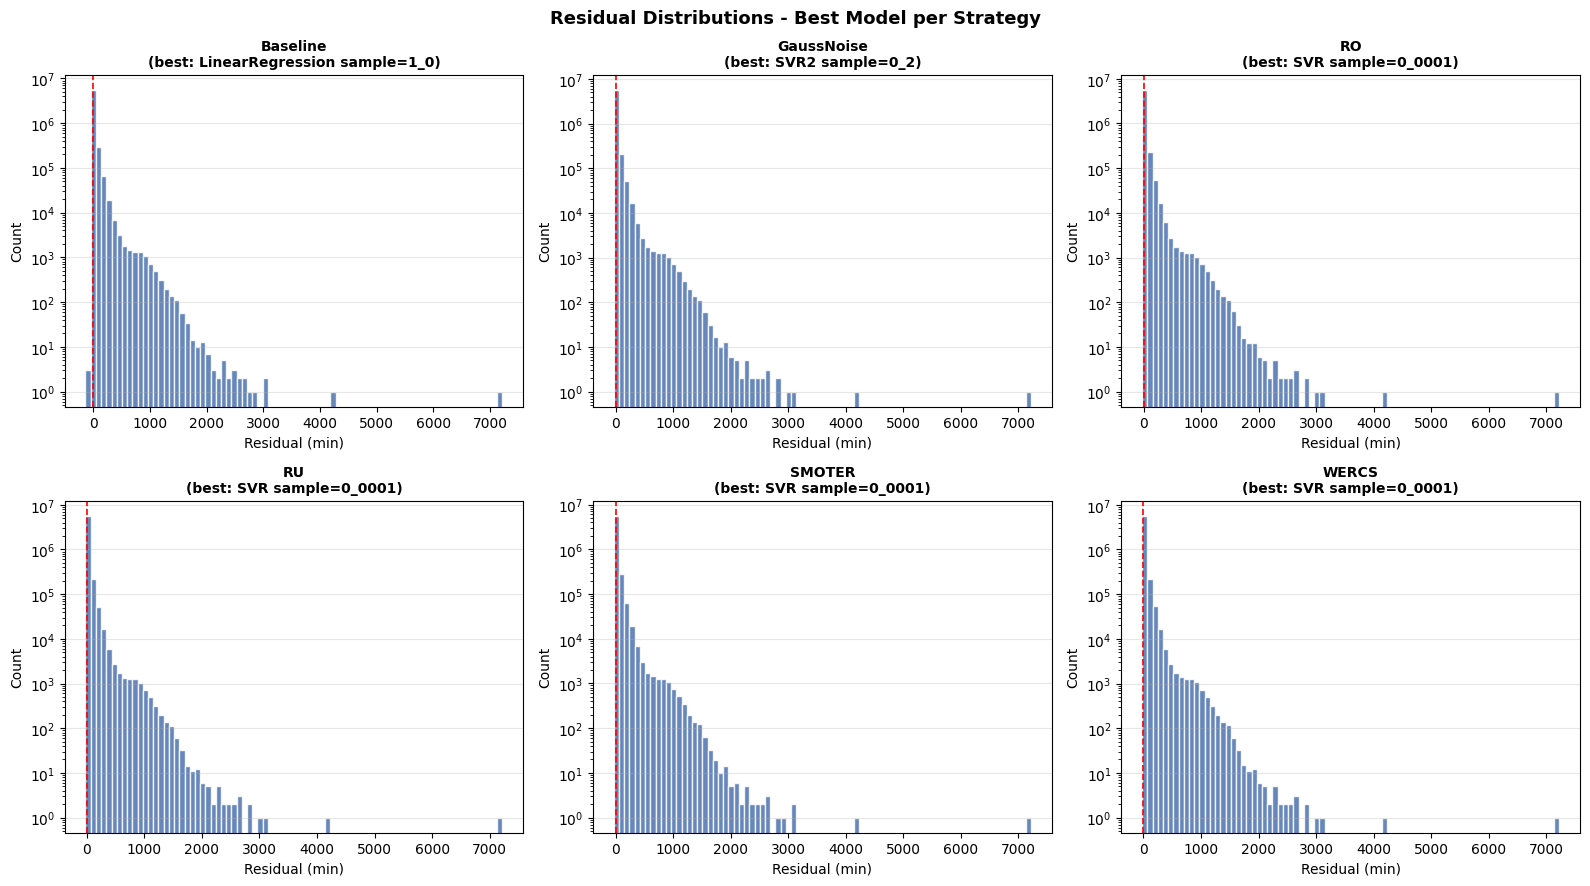

In [20]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
strategies_list = results_df.index.get_level_values('Strategy').unique().tolist()

for ax, strategy in zip(axes, strategies_list):
    best_idx_s   = results_df.xs(strategy, level='Strategy')['f1_phi'].idxmax()  # (model, sample)
    best_model_name, best_sample = best_idx_s
    model = all_models[(best_model_name, best_sample, strategy)]
    preds = np.clip(model.predict(X_test), 0, None)
    resid = y_test - preds
    ax.hist(resid, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f'{strategy}\n(best: {best_model_name} sample={best_sample})', fontsize=10, weight='bold')
    ax.set_xlabel('Residual (min)')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Residual Distributions - Best Model per Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/residual_distribution.png")

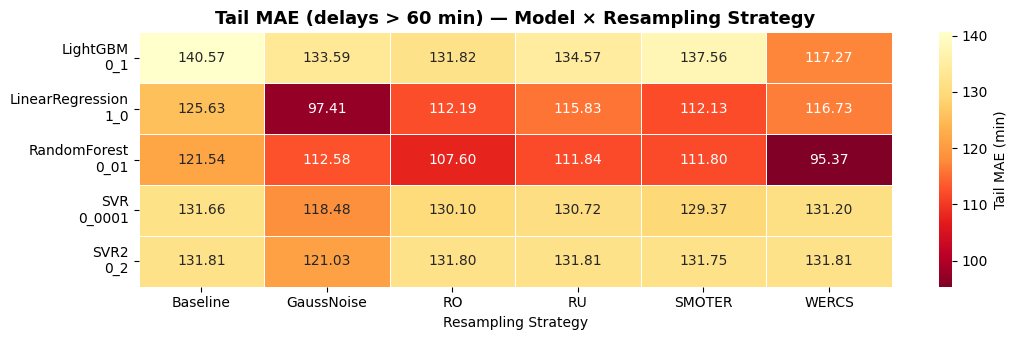

In [21]:
import seaborn as sns
from matplotlib import pyplot as plt

tail_mae_pivot = results_df['Tail_MAE'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, len(tail_mae_pivot) * 0.5 + 1))
sns.heatmap(
    tail_mae_pivot,
    annot=True, fmt='.2f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Tail MAE (min)'}
)

labels = []
for i, (model, sample) in enumerate(tail_mae_pivot.index):
    prev = tail_mae_pivot.index[i - 1] if i > 0 else None
    labels.append(f'{model}\n{sample}' if prev is None or prev[0] != model else sample)

ax.set_yticklabels(labels, rotation=0)
ax.set_title('Tail MAE (delays > 60 min) — Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/heatmap_tail_mae.png', dpi=150, bbox_inches='tight')
plt.show()